## Remote content Head-direction

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, Imu

[2026-04-27 11:01:09,391][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[11:01:22][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:01:22][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:01:22][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[11:01:23][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.helpers import interpolate_to_new_time

In [5]:
from spyglass.shijiegu.gyroscope import load_tracking_result, load_tracking_data_position

In [6]:
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd

### Test the whole angle calculation pipeline

In [7]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="ephys_head_direction_b")

[11:01:32][INFO] Spyglass: Starting {'export_id': 99}
INFO:spyglass:Starting {'export_id': 99}


In [8]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals = {}, {}, {}

In [9]:
animal = "julio"
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [10]:
animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [11]:
animal = "molly"
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [12]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMindRemoteTheta

In [13]:
angles_animals = {}

theta_params = "params_both_max_run_time_2_state"
classifier_param_name = None

for animal in ["molly","julio","klein"]:
    list_of_days = list_of_days_animals[animal]
    encoding_set = encoding_set_animals[animal]
    classifier_param_name = classifier_param_name_animals[animal]
    proportion = 0.1
    
    (angles_animals[animal], v1, v2,
     max_posterior_2d, head_orientation, animal_location,
     parsed_info, parsed_arm) = find_angle_animal(
                        animal, list_of_days, list_of_days,
                        theta_params,
                        encoding_set,
                        classifier_param_name, proportion,
                        debug = False, use_gyro = True, imu_param_name = "big_acc_bias")

Loading from spyglass database instead of pickle file.
molly20220416_.nwb
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 2, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 4, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 6, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 10, 'minimum_duration': 0.02, 'remote_parameter': 'dur_0.02_sum_0.2', 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
molly20220417_.nwb
molly20220418_.nwb
molly20220419_.nwb


In [14]:
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/angle.pkl'
#file_path = 'angle.pkl' # Common extensions are .pkl or .pickle

with open(output_path, 'wb') as file:
    pickle.dump(angles_animals, file)

In [15]:
#angles_animals[animal]

In [16]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_head_direction_b")

### Plotting

In [17]:
from scipy.stats import binomtest
import starbars
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(p,N):
    return np.sqrt(p*(1-p)/N)

def plot_one_axis(p, N, animal_ind, ax, animal, draw_annotation = True, draw_text = False):
    q = 1 - p
    std = [sd_err(p,N), sd_err(q,N)]
    mean = [p, q]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],color = color_by_rat[animal], alpha=0.8)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)

    pN = int(p*N)
    res = binomtest(pN, N, 0.5, alternative = "less")
    p_value = res.pvalue
    print("p_value",p_value)
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

### Raw angle

In [18]:
VISUAL_FIELD = 110
VISUAL_FIELD_RAD = VISUAL_FIELD/180 * np.pi

In [19]:
output_path = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/angle.pkl'

with open(output_path, 'rb') as file:
    loaded_data = pickle.load(file)

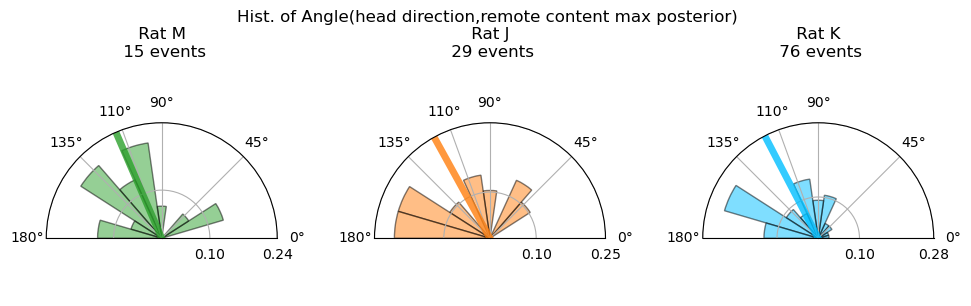

In [20]:
# Create a figure and a polar subplot
fig, axes = plt.subplots(1,3, figsize = (12,3),
                         subplot_kw={'projection': 'polar'})

ind = 0
for animal in ["molly","julio","klein"]:
    angles = loaded_data[animal]
    n, bins, patches = axes[ind].hist(angles, weights = np.ones(len(angles))/len(angles),
                                      bins=np.linspace(0,np.pi,12), alpha=0.5,
                                      color=color_by_rat[animal], edgecolor='black')
    axes[ind].axvline(np.mean(angles), color = color_by_rat[animal], linewidth = 5,
                      alpha = 0.8)
    # axes[ind].plot(VISUAL_FIELD_RAD, color = 'k', linewidth = 3, linestyle = ":",
    #                   alpha = 0.5)

    # Set the title
    if ind == 1:
        axes[ind].set_title(f'Hist. of Angle(head direction,remote content max posterior) \n Rat {animal[0].upper()} \n {len(angles)} events')
    else:
        axes[ind].set_title(f'\n Rat {animal[0].upper()} \n {len(angles)} events')
    axes[ind].set_thetamin(0)
    axes[ind].set_thetamax(180)
    ymin, ymax = axes[ind].get_ylim()
    ymax = np.round(ymax+0.03,2)
    axes[ind].set_rticks([0.1, ymax]) #
    axes[ind].set_ylim([ymin, ymax])
    axes[ind].set_thetagrids([0, 45, 90, 135, VISUAL_FIELD, 180])
    
    ind += 1

#plt.show()

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure4/content_angle"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png") 

### Within field vs out-of-field

In [22]:
#fig, ax = plt.subplots(1,1, figsize = (4,3))

ind = 0
for animal in ["molly","julio","klein"]:
    angles = loaded_data[animal]
    N = len(angles)
    in_field = np.sum(np.array(angles) < VISUAL_FIELD_RAD)/N
    out_field = np.sum(np.array(angles) > VISUAL_FIELD_RAD)/N
    print(animal, "out_field",out_field)
    ind += 1

    #plot_one_axis(in_field, N, ind, ax, animal, draw_annotation = True, draw_text = False)

molly out_field 0.6666666666666666
julio out_field 0.5517241379310345
klein out_field 0.5394736842105263
